# Gmsh export and FEA validation of the analytical layer

Layer 3 generates geometry and meshes for external open-source tools instead
of reimplementing FEM. This example:

1. exports the **2D unrolled** cross-section (the annulus linearized at the
   mean radius — one pole pair, periodic) and a **3D sector** mesh via Gmsh;
2. solves open-circuit 2D magnetostatics with **GetDP** (if installed) or
   loads committed golden results;
3. compares the FEA gap field against the Phase-1 load line — and *measures*
   the Carter factor from a slotless/slotted pair.

Requires `pip install "axfluxmdo[fea]"`; GetDP is optional
(ONELAB bundle, or set `AXFLUXMDO_GETDP=/path/to/getdp`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from axfluxmdo import AxialFluxMotor
from axfluxmdo.solvers import GapFieldSolution, find_getdp
from axfluxmdo.solvers.gmsh_export import export_3d_sector, export_mesh
from axfluxmdo.validation import compare_open_circuit, measured_carter_factor
from axfluxmdo.viz import plot_gap_field

HERE = Path(__file__).parent if "__file__" in globals() else Path(".")
OUTPUT_DIR = HERE / "output"
DATA_DIR = HERE / "data"
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
MAGNET_TEMP_C = 65.0  # ambient 25 C + 40 C rise: the analytical model's assumption

## Mesh export

The unrolled model: x is the circumferential direction over one pole pair,
y is axial. Slotless puts stator iron directly at the gap face (the load
line's magnetic circuit); slotted opens winding slots.

In [2]:
msh_slotless, layout = export_mesh(motor, OUTPUT_DIR / "linear2d_slotless.msh")
msh_slotted, _ = export_mesh(motor, OUTPUT_DIR / "linear2d_slotted.msh", slotted=True)
msh_3d = export_3d_sector(motor, OUTPUT_DIR / "sector3d.msh", mesh_size_factor=2.0)
for p in (msh_slotless, msh_slotted, msh_3d):
    print(f"{p.name}: {p.stat().st_size / 1024:.0f} kB")

linear2d_slotless.msh: 158 kB
linear2d_slotted.msh: 350 kB
sector3d.msh: 52 kB


## Mesh view (matplotlib, headless-safe)

Info    : Reading '/Users/johnhodge/Documents/code/axfluxmdo/examples/output/linear2d_slotted.msh'...
Info    : 3549 nodes
Info    : 7096 elements
Info    : Storing section $Periodic as model attribute
Info    : Done reading '/Users/johnhodge/Documents/code/axfluxmdo/examples/output/linear2d_slotted.msh'


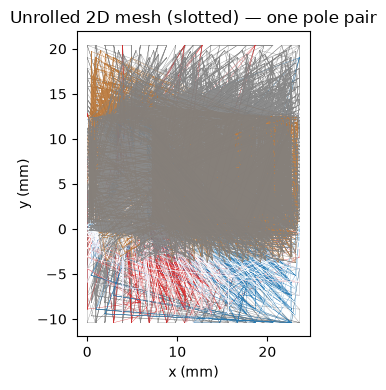

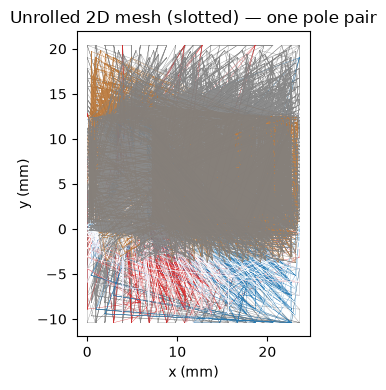

In [3]:
import gmsh  # noqa: E402

gmsh.initialize()
gmsh.open(str(msh_slotted))
_, coords, _ = gmsh.model.mesh.getNodes()
xyz = coords.reshape(-1, 3)
tri_groups = []
for dim, tag in gmsh.model.getPhysicalGroups(2):
    name = gmsh.model.getPhysicalName(dim, tag)
    tris = []
    for ent in gmsh.model.getEntitiesForPhysicalGroup(dim, tag):
        etypes, _, enodes = gmsh.model.mesh.getElements(dim, ent)
        for etype, nodes in zip(etypes, enodes, strict=True):
            if etype == 2:  # 3-node triangles
                tris += list((nodes.reshape(-1, 3) - 1).astype(int))
    if tris:
        tri_groups.append((name, tris))
gmsh.finalize()

fig, ax = plt.subplots(figsize=(11, 4))
colors = {
    "ROTOR_IRON": "0.5",
    "MAGNET_N": "#d62728",
    "MAGNET_S": "#1f77b4",
    "AIR": "#f0f0ff",
    "AIRGAP": "#ffffff",
    "WINDING": "#b87333",
    "STATOR_IRON": "0.5",
}
for name, tris in tri_groups:
    t = mtri.Triangulation(xyz[:, 0] * 1e3, xyz[:, 1] * 1e3, tris)
    ax.tripcolor(t, facecolors=[1.0] * len(tris), cmap="Greys", alpha=0.0)
    ax.triplot(t, lw=0.25, color=colors.get(name, "k"), alpha=0.9)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Unrolled 2D mesh (slotted) — one pole pair")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_mesh_2d.png", dpi=150, bbox_inches="tight")
fig

## Open-circuit solve (GetDP) or golden results

With GetDP installed this runs the live pipeline (mesh → .pro → solve →
parse, well under a second per case). Without it, committed golden tables
from a pinned GetDP run are loaded so the comparison below always renders.

In [4]:
GOLDEN_SLOTLESS = DATA_DIR / "06_gap_field_slotless.dat"
GOLDEN_SLOTTED = DATA_DIR / "06_gap_field_slotted.dat"

sol_slotless = sol_slotted = None
if find_getdp() is not None:
    from axfluxmdo.solvers import solve_open_circuit

    print("getdp found: running the live pipeline")
    sol_slotless = solve_open_circuit(motor, magnet_temp_c=MAGNET_TEMP_C)
    sol_slotted = solve_open_circuit(motor, slotted=True, magnet_temp_c=MAGNET_TEMP_C)
elif GOLDEN_SLOTLESS.exists():
    print("getdp not found: loading committed golden results")
    sol_slotless = GapFieldSolution.from_table(GOLDEN_SLOTLESS, motor, magnet_temp_c=MAGNET_TEMP_C)
    sol_slotted = GapFieldSolution.from_table(
        GOLDEN_SLOTTED, motor, magnet_temp_c=MAGNET_TEMP_C, slotted=True
    )
else:
    print(
        "Neither getdp nor golden data available — install GetDP (ONELAB bundle) "
        "or set AXFLUXMDO_GETDP to run the validation section."
    )

getdp not found: loading committed golden results


## FEA vs the analytical load line

The FEA and the load line share the identical recoil-line magnet model, so
the residual isolates geometry: inter-magnet fringing and finite iron
permeability. Expect a few percent.

Open-circuit comparison (slotless, magnets at 65 °C)
  B_g: 1.0164 T (analytical) vs 0.9029 T (FEA)  ->  -11.16%
  B_1: 1.2583 T (analytical) vs 1.1727 T (FEA)  ->  -6.81%


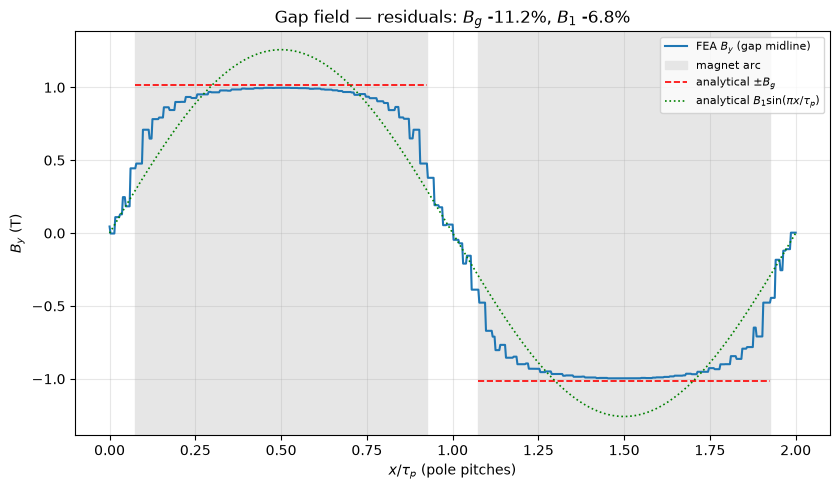

In [5]:
if sol_slotless is not None:
    comparison = compare_open_circuit(motor, sol_slotless, magnet_temp_c=MAGNET_TEMP_C)
    print(comparison)
    fig = plot_gap_field(sol_slotless, comparison)
    fig.savefig(OUTPUT_DIR / "06_gap_field.png", dpi=150, bbox_inches="tight")
    fig

## Measuring the Carter factor

Slotting locally weakens the gap field; the classical correction multiplies
the effective gap by the Carter factor k_C. Here FEA *measures* it from the
slotless/slotted ratio (which cancels the common fringing bias) — and the
previously dormant `carter_factor` parameter of `airgap_flux_density` earns
its keep: the closure holds in ratio form,
B_loadline(1)/B_loadline(k_C) == B_FEA_slotless/B_FEA_slotted.

In [6]:
if sol_slotted is not None:
    from axfluxmdo.materials import airgap_flux_density

    k_c = measured_carter_factor(sol_slotless, sol_slotted, motor)
    ratio_loadline = airgap_flux_density(
        motor.magnet, motor.magnet_thickness, motor.air_gap, MAGNET_TEMP_C
    ) / airgap_flux_density(
        motor.magnet, motor.magnet_thickness, motor.air_gap, MAGNET_TEMP_C, carter_factor=k_c
    )
    ratio_fea = sol_slotless.mean_b_t / sol_slotted.mean_b_t
    print(f"measured Carter factor: k_C = {k_c:.4f}")
    print(f"slotting knockdown — FEA ratio: {ratio_fea:.4f}")
    print(f"                load line(k_C): {ratio_loadline:.4f}")
    cmp_slotted = compare_open_circuit(motor, sol_slotted, magnet_temp_c=MAGNET_TEMP_C)
    print(cmp_slotted)

    # Feed the measurement back into the analytical layer: both models accept
    # carter_factor, correcting torque/field predictions for slotting.
    from axfluxmdo import OperatingPoint
    from axfluxmdo.models import AnalyticalModel

    op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)
    corrected = AnalyticalModel(carter_factor=k_c).evaluate(motor, op)
    uncorrected = AnalyticalModel().evaluate(motor, op)
    print(
        f"torque, slotless load line: {uncorrected.torque_nm:.2f} N·m; "
        f"with measured k_C: {corrected.torque_nm:.2f} N·m"
    )

measured Carter factor: k_C = 1.4384
slotting knockdown — FEA ratio: 1.0761
                load line(k_C): 1.0761
Open-circuit comparison (slotted, magnets at 65 °C)
  B_g: 1.0164 T (analytical) vs 0.8391 T (FEA)  ->  -17.44%
  B_1: 1.2583 T (analytical) vs 1.1087 T (FEA)  ->  -11.89%
torque, slotless load line: 8.63 N·m; with measured k_C: 8.02 N·m
